In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

!pip install flowio

In [ ]:
import shutil
import pandas as pd
import random

import copy
import numpy as np # Import numpy for checking finite values
import matplotlib.pyplot as plt # Import matplotlib for potential debugging

import os
import math # Import math for ceil
from sklearn.manifold import TSNE # Import TSNE to check default perplexity

PYTHONHASHSEED = '42'
TF_DETERMINISTIC_OPS = '1'
TF_CUDNN_DETERMINISTIC = '1'
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # For CuDNN ops

import glob
import json
import tensorflow as tf
import sys
from itertools import zip_longest

from sklearn import metrics
import pickle
import time
import csv
import traceback
import gc


from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score

In [ ]:

#fixed_path = 'C:\\Users\\Enrico Didoli\\0.Master_Thesis\\'
#fixed_path = 'C:\\Users\\admin\\0.Master_Thesis\\'
fixed_path = '/content/drive/MyDrive/0.Master_Thesis/'

if fixed_path not in sys.path:
    sys.path.append(fixed_path)

old_cellcnn_path = f'{fixed_path}CellCNN/Ubuntu/Old_CellCNN/old_cellCnn/'
if old_cellcnn_path not in sys.path:
    sys.path.append(old_cellcnn_path)

cellcnn_path = f'{fixed_path}CellCNN/Ubuntu/'
if cellcnn_path not in sys.path:
    sys.path.append(cellcnn_path)

general_functions_path = f'{fixed_path}General_Functions/'
if general_functions_path not in sys.path:
    sys.path.append(general_functions_path)

save_path = f'{fixed_path}CellCNN/Ubuntu/results/'
if save_path not in sys.path:
    sys.path.append(save_path)

other_functions_path = f'{cellcnn_path}New running ipynb/Final_notebooks/modules/'
if other_functions_path not in sys.path:
    sys.path.append(other_functions_path)


In [ ]:
decache_files = ['timepoints_elaboration', 'results_elaboration', 'new_datasets_generation', 'run_models',
                 'model', 'utils', 'downsample', 'model_grid',
                'All_fixed_functions', 'functions']

# Rimuovi il modulo specifico dalla cache
from timepoints_elaboration import remove_from_cache
remove_from_cache(decache_files)

# import downloaded modules
from model_grid import CellCnn

import utils as utils
import downsample as downsample

from timepoints_elaboration import load_data, donation_extraction, dataset_elaboration
from timepoints_elaboration import donor_division, patient_code_extraction, remove_from_cache

from results_elaboration import extract_hyper, phenotype_prediction, default_serializer, show_hyperparameters
from results_elaboration import elaborate_predictions, show_hyper


from run_models import  trials_train_CellCNN_old, trials_test_CellCNN_old

from new_datasets_generation import splitting_and_dataset_elaboration

from functions import remove_labels, show_blast_distribution_perc, train_val_finalizing, prepare_results_to_save, retrieve_labels
from functions import subset_sampling, flatten, generate_LOPOCV_dicts, generate_LOPOCV_folds, extract_fold_features, val_res_pred
from functions import find_robust_threshold, test_res_pred, generate_seeds, run_training, save_models, nsub_ncells_comb, find_theta_best



timepoints_elaboration rimosso dalla cache
results_elaboration rimosso dalla cache
new_datasets_generation rimosso dalla cache
run_models rimosso dalla cache
model non trovato nella cache
utils rimosso dalla cache
downsample rimosso dalla cache
model_grid rimosso dalla cache
All_fixed_functions non trovato nella cache


In [ ]:


def load_models(model, meta):
        model = CellCnn()

        model.scale = meta['scale']
        model.quant_normed = meta['quant_normed']
        model.regression = meta['regression']
        model.nsubset = meta['nsubset']
        model.ncell = meta['ncell']
        model.per_sample = meta['per_sample']
        model.subset_selection = meta['subset_selection']
        model.maxpool_percentages = meta['maxpool_percentages']
        model.nfilter_choice = meta['nfilter_choice']
        model.learning_rate = meta['learning_rate']
        model.coeff_l1 = meta['coeff_l1']
        model.coeff_l2 = meta['coeff_l2']
        model.dropout = meta['dropout']
        model.dropout_p = meta['dropout_p']
        model.max_epochs = meta['max_epochs']
        model.patience = meta['patience']
        model.dendrogram_cutoff = meta['dendrogram_cutoff']
        model.accur_thres = meta['accur_thres']
        model.verbose = meta['verbose']
        model.resampled = meta['resampled']
        model.seed = meta['seed']
        model.results = meta['results']
        model.grid = meta['grid']

        return model

In [ ]:


def get_actual_size(obj):
    """Get TRUE memory size"""
    if isinstance(obj, pd.DataFrame):
        return obj.memory_usage(deep=True).sum()
    elif isinstance(obj, pd.Series):
        return obj.memory_usage(deep=True)
    elif isinstance(obj, np.ndarray):
        return obj.nbytes
    elif isinstance(obj, (list, tuple, set, dict)):
        # For containers, sum up contents
        return sys.getsizeof(obj) + sum(sys.getsizeof(item) for item in obj)
    else:
        return sys.getsizeof(obj)

def print_var_memory(var_to_check = None):
    # Display all variables with ACTUAL sizes
    all_vars = %who_ls
    sizes = []
    if var_to_check is None:
        var_to_check = all_vars


    for var_name in all_vars:
        #try:
            var = eval(var_name)

            #if var_name in  ('train_datasets_extracted','val_datasets_extracted','test_datasets_extracted'):
            if var_name in var_to_check:
                #print(var)
                if isinstance(var, (list, tuple)):
                    var = flatten(var)
                    tot = 0
                    for element in var:
                        tot += get_actual_size(element)
                    size = tot
                    sizes.append((var_name, type(var).__name__, size))
            else:
                size = get_actual_size(var)
                sizes.append((var_name, type(var).__name__, size))

        #except:
        #    pass

    # Sort by size
    sizes.sort(key=lambda x: x[2], reverse=True)

    # Pretty print
    print(f"{'Variable':<25} {'Type':<20} {'Memory':>15}")
    print("-" * 65)
    total = 0
    var_to_check = []
    for name, type_name, size in sizes:
        total += size
        if size > 1024**3:  # GB
            print(f"{name:<25} {type_name:<20} {size/(1024**3):>12.2f} GB")
            var_to_check.append(name)

        elif size > 1024**2:  # MB
            print(f"{name:<25} {type_name:<20} {size/(1024**2):>12.2f} MB")
            var_to_check.append(name)
        '''
        elif size > 1024:  # KB
            print(f"{name:<25} {type_name:<20} {size/1024:>12.2f} KB")

        else:
            print(f"{name:<25} {type_name:<20} {size:>12} bytes")
        '''
    print("-" * 65)
    print(f"{'TOTAL':<25} {'':<20} {total/(1024**3):>12.2f} GB")
    return var_to_check

print_var_memory()

Variable                  Type                          Memory
-----------------------------------------------------------------
-----------------------------------------------------------------
TOTAL                                                  0.00 GB


[]

# Training


In [ ]:

tuning_exp = 'Trial_5_fix_code_NO_AS_bayesian_tuning'


config_save_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/'
os.makedirs(config_save_dir, exist_ok=True)

with open(os.path.join(config_save_dir, 'config.pkl'), 'rb') as f:
            config = pickle.load(f)

starting_seed = config['starting_seed']
n_sub = config['n_sub ']
n_cells = config['n_cells']
blast_perc = config['blast_perc']
nfilter = config['nfilter']
maxpool_p = config['maxpool_p']
learning_r = config['learning_r']
labels = config['labels']  # if False internal data augmentation do not takes in account true subset condition

hyper = (nfilter, maxpool_p, learning_r)

print(starting_seed)
print(n_sub)
print(n_cells)
print(blast_perc)
print(nfilter)
print(maxpool_p)
print(learning_r)
print(labels)


1000
3
100000
[0.0001, 0.001, 0.01]
[5, 7, 9]
[0.01, 1, 10, 100]
[0.001, 0.005]
False
False


In [ ]:
%%time

# Trova tutti i file con estensione specifica in una cartella
data_folder = f'{fixed_path}B-ALL_Datasets'
extension = '*.csv'  # cambia con l'estensione che ti serve

multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)#, remove_control = True)



0.09
Elaborating file 0: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE1_D15_2.csv
0.0
Elaborating file 1: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE1_D78.csv
0.16
Elaborating file 2: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D15_1.csv
0.01
Elaborating file 3: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D29_1.csv
0.0
Elaborating file 4: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D71_1.csv
0.15
Elaborating file 5: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE12_D15_2.csv
0.0
Elaborating file 6: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE12_D29_1.csv
39.56
Elaborating file 7: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE2_D15_2.csv
15.06
E

In [ ]:

full_LOPOCV_dicts = generate_LOPOCV_dicts(multiple_donations, ALL_DATASETS)
LOPOCV_patients_folds = generate_LOPOCV_folds(full_LOPOCV_dicts, ALL_DATASETS, starting_seed)

In [ ]:
    outer_fold = 9
    seed_load_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/outer_fold_{outer_fold}/'
    with open(os.path.join(seed_load_dir, 'tuning_seed_info.pkl'), 'rb') as f:
                        seed_info = pickle.load(f)
    print(seed_info)

{'starting_seed': 1000, 'LOPOCV_fold_idx': 9, 'fold_base_seed': 901000, 'final_tuning_base_seed': 912510}


{'robust_threshold': 0.5, 'roc_threshold': 0.6408588886260986, 'best_nsub': 450, 'best_ncells': 600, 'tested_par': [[200, 200], [200, 400], [400, 400], [400, 400], [400, 350], [500, 150], [500, 250], [600, 150], [700, 500], [400, 700], [100, 100], [200, 500], [300, 200], [300, 450], [600, 450]], 'val_predicted_for_roc': [[[[[[0.0017977499203425396, 0.9982022841771444], [0.5270168160398802, 0.4729831665754318], [0.0008061492517867919, 0.9991938471794128], [0.04535718370849887, 0.9546427925427755]]], [1, 0, 1, 1]], [[[[0.0014344303187759921, 0.9985655744870504], [0.4369127576549848, 0.5630872249603271]]], [1, 0]], [[[[0.07334782121082146, 0.926652173201243], [0.08866039415200551, 0.9113396008809408], [0.11432693277796109, 0.8856730858484904], [0.05977507991095384, 0.9402249256769816], [0.10784036169449489, 0.892159620920817], [0.21085638801256815, 0.7891436020533243]]], [1, 1, 0, 1, 1, 0]], [[[[0.10761696348587672, 0.8923830389976501], [0.13030411675572395, 0.8696958621342977], [0.086517

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

✅ Metadata salvati in /content/drive/MyDrive/0.Master_Thesis/CellCNN/Ubuntu//experiments/experiment_Trial_4_AS_Ensemble/outer_fold_9/ensemble/training/inner_fold_0/models/seed_0/metadata.pkl
Load again data
test_pat: ['12']
0.09
Elaborating file 0: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE1_D15_2.csv
0.0
Elaborating file 1: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE1_D78.csv
0.16
Elaborating file 2: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D15_1.csv
0.01
Elaborating file 3: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D29_1.csv
0.0
Elaborating file 4: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D71_1.csv
0.15
Elaborating file 5: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE12_D15_2.csv
0.0
Elaborating file 6: /content

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
Done
Trial 1 Done!

Trial 0 Accuracy: 1.0
Trial 0 F1_score: 1.0
Trial 0 F1_score: 1.0
             0  1
0            1  1
True Labels  1  1
mean_accuracy over the ten trials: 1.0
accuracy_std over the ten trials: 0.0
mean_f1 over the ten trials: 1.0
std_f1 over the ten trials: 0.0
mean_recall over the ten trials: 1.0
std_recall over the ten trials: 0.0
Save Direct Prediction results
Start Robust prediction using ROC threshold
[[1, 1]]
50
[50]
[50]
[[]]
Prediction 1
50
Trial 1 out of 1 started!
Prediction started...
seed: 27948. Type: <class 'numpy.int64'>
seed: 27948. Type: <class 'int'>


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step
Done
Trial 1 Done!

Len of Mean: 50
[43068]
Prediction 3
Trial 1 out of 1 started!
Prediction started...
seed: 43068. Type: <class 'numpy.int64'>
seed: 43068. Type: <class 'int'>


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step
Done
Trial 1 Done!

Len of Mean: 50
[270984]
Prediction 4
Trial 1 out of 1 started!
Prediction started...
seed: 270984. Type: <class 'numpy.int64'>
seed: 270984. Type: <class 'int'>


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step
Done
Trial 1 Done!

Len of Mean: 50
[0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8648648648648649, 0.8653326122228231, 0.8662

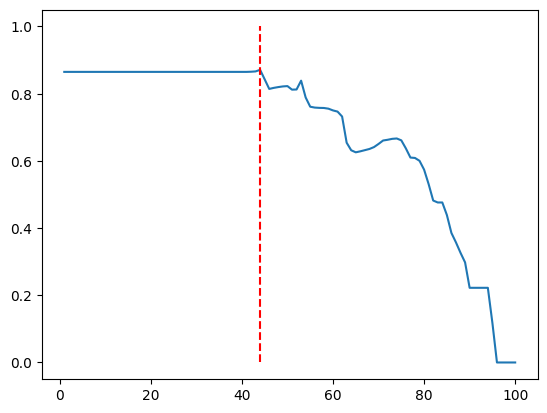

In [ ]:
%%time

colab = True # if bayesian tuning results are from colab
start_lopocv_fold = 0
end_lopocv_fold = 0

tuning_exp = 'Trial_5_fix_code_NO_AS_bayesian_tuning'
exp = 'Trial_5_fix_code_AS_Ensemble'

save_memory = False # set True to save RAM memory
grid = True

weights_outdir = f'{config_save_dir}/weights'
os.makedirs(weights_outdir, exist_ok=True)
full_process_time_list = []

for LOPOCV_fold_idx, (train_kfolds, test_pat) in enumerate(LOPOCV_patients_folds): # for each LOPO fold
  if LOPOCV_fold_idx >= start_lopocv_fold:

    LOPOCV_start = time.time()

    # === Import Base seed === #
    seed_load_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/outer_fold_{LOPOCV_fold_idx}/'

    with open(os.path.join(seed_load_dir, 'tuning_seed_info.pkl'), 'rb') as f:
                            seed_info = pickle.load(f)

    print('check seeds:', seed_info)
    training_split_seed = seed_info['final_tuning_base_seed']
    fold_base_seed = seed_info['fold_base_seed']

    # === Import Tuned theta* === #

    tuning_load_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/outer_fold_{LOPOCV_fold_idx}/tuning/results'

    with open(os.path.join(tuning_load_dir, 'best_ncells.pkl'), 'rb') as f:
                        best_ncells = pickle.load(f)

    with open(os.path.join(tuning_load_dir, 'best_nsub.pkl'), 'rb') as f:
                        best_nsub = pickle.load(f)

    print(f'Theta*: {best_ncells, best_nsub}')


    base_seed = fold_base_seed

    if save_memory:
        if LOPOCV_fold_idx != start_lopocv_fold:
            multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)


    # === Generate AS per each fold === #

    # retrieve train and val patients per fold
    fold_features = extract_fold_features(train_kfolds, multiple_donations, tot_perc_list) #Fold feature dictionary creation
    print(f'Start Artificial Sample generation')
    AS_generating_start = time.time()

    base_final_training_AS_seed = base_seed

    # generate the Artificial Samples
    artificial_samples_folds = []
    for fold, (train_features, val_features) in fold_features.items():

        final_training_AS_seed = base_seed + fold
        train_donors_idx, val_donors_idx = train_features[0], val_features[0] # retrieve patients form fold features dictionary

        # extraxt samples using pre-slitted indexes
        train_datasets_extracted = donation_extraction(train_donors_idx, multiple_donations, ALL_DATASETS)
        val_datasets_extracted = donation_extraction(val_donors_idx, multiple_donations, ALL_DATASETS)
        test_datasets_extracted = donation_extraction(test_pat, multiple_donations, ALL_DATASETS)

        # generate Artificial Samples
        (new_train_datasets, new_train_y,
         new_val_datasets,   new_val_y, _, _ ) = splitting_and_dataset_elaboration(train_datasets_extracted,
                                                                            val_datasets_extracted,
                                                                            test_datasets_extracted,
                                                                            n_sub, n_cells,           # number of AS, number of cells per AS
                                                                            final_training_AS_seed, # seed for random extraction
                                                                            blast_perc = blast_perc,  # % of blast cells extracted
                                                                            per_perc = True)          # one Unhealthy AS per %

        # store generated AS
        artificial_samples_folds.append([new_train_datasets, new_train_y, new_val_datasets, new_val_y])#, new_test_datasets, new_test_y])

    if save_memory:
        # delete for RAM saving
        del ALL_DATASETS
        del test_datasets_extracted
        del train_datasets_extracted
        del new_train_datasets
        del new_val_datasets
        gc.collect()

    print(f'Time elapsed for AS generation: {AS_generating_start - time.time()}')
    print(f'End of Artificial Sample generation')

    # fix seed for comparisons
    base_seed = training_split_seed
    for i in range(1):


            # prepare storing variables
            best_thresholds = []       # save thresholds
            roc_metrics = []
            val_predicted_for_roc = [] # store predictions from tuning for threshold tuning

            print(f'Model {i+1}. Testing params -> ncells: {best_ncells}, nsubs: {best_nsub}')
            print(f'5 Fold CV started')

            val_predicted_for_roc_folds = []
            f1_across_folds = []

            for fold_idx, (train_features, val_features) in fold_features.items():
                print(f'\nCV Fold {fold_idx} starts (LOPOCV iteration: {LOPOCV_fold_idx})\n')
                fold_start = time.time()

                # Load data from stored fold-specific AS
                print('Loading data...')
                (new_train_datasets, new_train_y,
                 new_val_datasets, new_val_y) = artificial_samples_folds[fold_idx] # retrieve generated AS from pre-generated AS
                print('Data Loaded...')

                # remove labels (random search without labels is required)
                train, val = train_val_finalizing(new_train_datasets, new_val_datasets, grid, labels)

                tuning_predictions = []
                tuning_results = []

                trials = 1 ### 3  number of time the model have to be trained (at each time a different seed is used)

                # === Generate seed lists in advance === #

                train_CV_seed = base_seed + i*1000 + fold_idx*10 + 1
                seed_list = generate_seeds(len(LOPOCV_patients_folds)*2, seed = train_CV_seed)

                pred_CV_seed = base_seed + i*1000 + fold_idx*10 + len(fold_features)*10
                tuning_prediction_seed_list = generate_seeds(trials, seed = pred_CV_seed)

                base_seed += 200
                final_orig_pred_seed = base_seed
                original_prediction_seed_list = generate_seeds(trials, seed = final_orig_pred_seed)

                base_seed += 1000
                final_rob_pred_seed = base_seed
                robust_prediction_seed_list = generate_seeds(3, seed = final_rob_pred_seed)

                try:
                        # === Train Models === #

                        models_lists = run_training(CellCnn,
                                            train, new_train_y,
                                            new_val_datasets = val, new_val_y = new_val_y,
                                            new_test_datasets = None,
                                            seed_list =  seed_list, hyper = hyper, grid = grid, labels = labels,
                                            trials = trials,
                                            cells_per_sub = best_ncells, ## Tuned ncells ##
                                            best_nsub = best_nsub,        ## Tuned nsub   ##
                                            max_epochs = 1,              ### 100,
                                            nrun = None,                  #grid search, so doesn't matter wht number
                                            generate = False)



                        # === Save Models === #
                        for trial_i, model in enumerate(models_lists):
                            save_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/training/inner_fold_{fold_idx}/models/seed_{trial_i}'
                            os.makedirs(save_dir, exist_ok=True)
                            save_models(model, save_dir)

                        # === Prediction Approach: CellCNN with tau = 0.5 === #

                        if save_memory:
                            print('Load data for Test set')
                            multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)

                        test_datasets_extracted = donation_extraction(test_pat, multiple_donations, ALL_DATASETS)

                        original_test_datasets, original_test_y = retrieve_labels(test_datasets_extracted, remove = True, flat = True)
                        print(f'Ground thruth labels: {original_test_y}')

                        # Test set prediction
                        original_predictions_list, original_results_list = trials_test_CellCNN_old(models_lists, original_test_datasets, original_prediction_seed_list)

                        print('Save CellCNN Prediction results')
                        save_original_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/results/inner_fold_{fold_idx}/predictions/direct'
                        os.makedirs(save_original_dir, exist_ok=True)

                        with open(os.path.join(save_original_dir, 'original_predictions_list.pkl'), 'wb') as f:
                                        pickle.dump(original_predictions_list, f)
                        with open(os.path.join(save_original_dir, 'original_results_list.pkl'), 'wb') as f:
                                        pickle.dump(original_results_list, f)
                        with open(os.path.join(save_original_dir, 'original_test_y.pkl'), 'wb') as f:
                                        pickle.dump(original_test_y, f)

                        # === Prediction Approach: Resamplimg === #

                        print('Start Robust prediction using ROC threshold')

                        test_resample_n = 100000 #same dimension of AS
                        k = 2 ### 100

                        per_donor_original_test_datasets, per_donor_original_test_y = retrieve_labels(test_datasets_extracted, remove = False)
                        print(f'Ground thruth labels per patient: {per_donor_original_test_y}')

                        (_, #test_total_labels,               # Predicted resampled subsets labels
                            test_total_pred_lists,           # Mean predictions of resampled subsets across trials (per patient)
                            test_total_trial_pred_lists,     # Lists of trial predictions of resampled subsets (per patient)
                            per_donor_resampled_test_y       # True labels of resampled subsets (per patient)
                                                    ) = test_res_pred(
                                                        models_lists,
                                                        per_donor_original_test_datasets,
                                                        test_resample_n,
                                                        k,
                                                        roc_threshold,
                                                        trials,
                                                        seed = robust_prediction_seed_list[1])



                        save_robust_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/results/inner_fold_{fold_idx}/predictions/robust'
                        os.makedirs(save_robust_dir, exist_ok=True)

                        with open(os.path.join(save_robust_dir, 'test_total_trial_pred_lists.pkl'), 'wb') as f:
                                        pickle.dump(test_total_trial_pred_lists, f)
                        with open(os.path.join(save_robust_dir, 'per_donor_resampled_test_y.pkl'), 'wb') as f:
                                        pickle.dump(per_donor_resampled_test_y, f)
                        with open(os.path.join(save_robust_dir, 'per_donor_original_test_y.pkl'), 'wb') as f:
                                        pickle.dump(per_donor_original_test_y, f)


                except Exception as e:
                        print(f"Training error: {e}")
                        traceback.print_exc()

                fold_end = time.time()
                print('')
                print(f'End CV Fold {fold_idx}. Time Elapsed: {fold_start - fold_end}')
                print(f'Time elapsed from start LOPOCV iteration: {LOPOCV_start - fold_end}')
                print('')

            if save_memory:

                print_var_memory()
                del artificial_samples_folds
                del new_train_datasets
                del train
                del new_val_datasets
                del val
                gc.collect()

                print_var_memory()
                multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)

            try:

                        # === Threshold tuning: \tau^*_{ROC} and \tau^*_{RES} === #

                        print('Start Threshold tuning after the training')

                        ensemble_mean_probs_per_patient = []
                        ensamble_val_y = []
                        ensamble_roc_samples_predictions = []

                        tuning_models_dir = f'{cellcnn_path}experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/training/'
                        os.makedirs(tuning_models_dir, exist_ok=True)

                        fold_features = extract_fold_features(train_kfolds) #Fold feature dictionary creation

                        for fold_idx, (train_features, val_features) in fold_features.items():

                            # === Rebuild models per CV fold === #

                            model_trials_dir = f'{tuning_models_dir}/inner_fold_{fold_idx}/models/'
                            all_trials = os.listdir(model_trials_dir)

                            loaded_models_lists = []
                            for i, trial in enumerate(all_trials):
                                model_dir = f'{model_trials_dir}/seed_{i}'
                                with open(os.path.join(model_dir, 'metadata.pkl'), 'rb') as f:
                                    meta = pickle.load(f)

                                model = load_models(model, meta)
                                loaded_models_lists.append(model)

                            print(f'Iteration {fold_idx}: Models Loaded!')

                            thr_tuning_seed = base_seed + fold_idx*10
                            tuning_prediction_seed_list = generate_seeds(len(all_trials), seed = thr_tuning_seed)


                            # extraxt samples using pre-slitted indexes
                            val_donors_idx = val_features[0] # retrieve patients form fold features dictionary
                            val_datasets_extracted = donation_extraction(val_donors_idx, multiple_donations, ALL_DATASETS)
                            per_donor_original_val_datasets, per_donor_original_val_y = retrieve_labels(val_datasets_extracted, remove = False)

                            # === RES === #
                            val_resample_n = 100000 #same dimension of the AS
                            k = 2 ### 50

                            (_, # predictions divided by patient -> file -> sampled subsets pred
                             total_trial_pred_lists,
                             mean_probs_per_patient) = val_res_pred(loaded_models_lists, per_donor_original_val_datasets, val_resample_n, k, tuning_prediction_seed_list[0])

                            # RES
                            ensemble_mean_probs_per_patient += mean_probs_per_patient # means across weights initializations
                            ensamble_val_y += per_donor_original_val_y

                            # ROC
                            for patient in total_trial_pred_lists:
                              sample_mean_across_subsets_seeds = []
                              for sample in patient:
                                  mean_across_seeds = []
                                  for subset in sample[0]: # assume consistency in the number of subsets
                                      mean_across_seeds.append(np.mean(subset))
                                  sample_mean_across_subsets_seeds.append(np.mean(mean_across_seeds))
                              # store sample mean predictions across seeds and subsets
                              ensamble_roc_samples_predictions += sample_mean_across_subsets_seeds


                        base_seed += len(fold_features)*100

                        # Compute and Save RES
                        tuning_save_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/tuning/resampling/'
                        os.makedirs(tuning_save_dir, exist_ok=True)

                        ensemble_robust_threshold, tot_per_tr_f1_scores = find_robust_threshold(ensemble_mean_probs_per_patient, 'f1', closest = True)
                        ensemble_robust_threshold = ensemble_robust_threshold/100

                        with open(os.path.join(tuning_save_dir, 'ensemble_mean_probs_per_patient.pkl'), 'wb') as f:
                                pickle.dump(ensemble_mean_probs_per_patient, f) # prediction used to tune the threshold

                        with open(os.path.join(tuning_save_dir, 'ensemble_robust_threshold.pkl'), 'wb') as f:
                                pickle.dump(ensemble_robust_threshold, f) # prediction used to tune the threshold

                        with open(os.path.join(tuning_save_dir, 'tot_per_tr_f1_scores.pkl'), 'wb') as f:
                                pickle.dump(tot_per_tr_f1_scores, f) # prediction used to tune the threshold

                        with open(os.path.join(tuning_save_dir, 'total_trial_pred_lists.pkl'), 'wb') as f:
                                pickle.dump(total_trial_pred_lists, f) # prediction used to tune the threshold

                        # Compute and Save ROC
                        tuning_save_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/tuning/roc/'
                        os.makedirs(tuning_save_dir, exist_ok=True)

                        #### comupute roc curve on resampled to fine the best threshold
                        fpr, tpr, thresholds = metrics.roc_curve(flatten(ensamble_val_y), ensamble_roc_samples_predictions, pos_label=1)# compute ROC curve
                        show_thresholds = (fpr, tpr, thresholds)
                        optimal_idx = np.argmax(tpr >= 0.95)  # index of the threshold that has the highest tpr
                        ensemble_roc_threshold = thresholds[optimal_idx]    # extract the threshold

                        print(f"Best Threshold for MRD (Recall=100%): {ensemble_roc_threshold}")
                        with open(os.path.join(tuning_save_dir, 'ensamble_val_y.pkl'), 'wb') as f:
                                pickle.dump(ensamble_val_y, f) # prediction used to tune the threshold
                        with open(os.path.join(tuning_save_dir, 'ensemble_roc_threshold.pkl'), 'wb') as f:
                                pickle.dump(ensemble_roc_threshold, f) # prediction used to tune the threshold
                        with open(os.path.join(tuning_save_dir, 'ensamble_roc_samples_predictions.pkl'), 'wb') as f:
                                pickle.dump(ensamble_roc_samples_predictions, f) # prediction used to tune the threshold
                        with open(os.path.join(tuning_save_dir, 'show_thresholds.pkl'), 'wb') as f:
                                pickle.dump(show_thresholds, f) # prediction used to tune the threshold




            except Exception as e:
                        print(f'Post-training threshold tuning error!')
                        print(f"Training error: {e}")
                        traceback.print_exc()



            #save seeds outside the ensemble
            tuning_save_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/'
            os.makedirs(tuning_save_dir, exist_ok=True)


            with open(os.path.join(tuning_save_dir, 'seed_info.pkl'), 'wb') as f:
                                pickle.dump({
                                    'starting_seed': starting_seed,
                                    'LOPOCV_fold_idx': LOPOCV_fold_idx,
                                    'fold_base_seed': fold_base_seed,
                                    'base_final_training_AS_seed': base_final_training_AS_seed,
                                    'training_split_seed': training_split_seed,
                                    'final_base_seed': base_seed
                                }, f)

            elapsed_time_for_LOPOCV = time.time() - LOPOCV_start
            print(f'elapsed_time_for_LOPOCV fold {LOPOCV_fold_idx}: {elapsed_time_for_LOPOCV}')

            with open(os.path.join(tuning_save_dir, 'elapsed_time_for_LOPOCV.pkl'), 'wb') as f:
                                pickle.dump(elapsed_time_for_LOPOCV, f)

    full_process_time_list.append(elapsed_time_for_LOPOCV)
    if LOPOCV_fold_idx >= end_lopocv_fold:
        break

